In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import os, sys
import numpy as np
import pandas as pd

current_path = os.getcwd()
sys.path.append(os.path.join(current_path, '..'))

from adapt_model import parse_experiment_name
from utils.globals import *

pd.set_option("display.max_rows", 60)

In [3]:
model_name = 'almar_13B'

num_layers_map = {
    'almar_13B': [3, 5, 7, 9, 11, 12, 14]
}

languages_map = {
    'almar_13B': ['en', 'de', 'cs', 'cs_de_en']
}

variable_parameters = {
    'num_layers': num_layers_map[model_name],
    'factual_thr': [0.0, 0.05, 0.1, 1.0],
    'languages': languages_map[model_name]
}



In [4]:
def load_data_file(model_name, method, experiment_name, test_file):
    if experiment_name and 'method' != 'original':
        result_dir = experiment_name
    else:
        result_dir = model_name
    result_file = os.path.join(RESULTS_DIR, method, result_dir, test_file)
    try:
        with open(result_file, 'r') as f:
            results = json.load(f)
    except FileNotFoundError:
        print(f"File {result_file} not found")
        results = None

    return results

Translation results to target

In [5]:
def parse_translation_results(train_lang, layers, fact_thr, result_dir):
    out_row = {'language': train_lang, 'layers': layers, 'threshold': fact_thr}

    for test_lang, tmp_res in result_dir.items():
        if tmp_res is None:
            out_row[f'{test_lang}_comet'] = 0.
            out_row[f'{test_lang}_chrf'] = 0.
        else:
            out_row[f'{test_lang}_comet'] = tmp_res['comet'] * 100. if 'comet' in tmp_res else 0.
            out_row[f'{test_lang}_chrf'] = tmp_res['chrf'] if 'chrf' in tmp_res else 0.
    return out_row

In [6]:
wmt_2tgt_res = pd.DataFrame(columns=['language', 'layers', 'threshold', 'de_comet', 'de_chrf', 'cs_comet', 'cs_chrf',
                                     'ru_comet', 'ru_chrf'])


tmp_res_dir = {lang: load_data_file(model_name, 'original', None, f'res_translation_WMT22-Test_en-{lang}.json' )
                for lang in ['de', 'cs', 'ru']}

wmt_2tgt_res.loc[len(wmt_2tgt_res)] = parse_translation_results('None', 0, 0.0, tmp_res_dir)

for train_lang in variable_parameters['languages']:
    for num_layers in variable_parameters['num_layers']:
        for fact_thr in variable_parameters['factual_thr']:
            if fact_thr == 0.0:
                experiment_name = f"{model_name}_{num_layers}L"
            else:
                experiment_name = f"{model_name}_{num_layers}L_factual_{fact_thr}"

            if train_lang != 'en':
                experiment_name += f"_{train_lang}"

            tmp_res_dir = {lang: load_data_file(model_name, 'DAMA_L', experiment_name,
                                                f'res_translation_WMT22-Test_en-{lang}.json')
                           for lang in ['de', 'cs', 'ru']}

            if all([tmp_res is None for tmp_res in tmp_res_dir.values()]):
                continue
            wmt_2tgt_res.loc[len(wmt_2tgt_res)] = parse_translation_results(train_lang,num_layers, fact_thr, tmp_res_dir)

File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_en-de.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_en-cs.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_en-ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_en-de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_en-cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_en-ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_en-de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_en-cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_en-ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0/res_translation_WMT22-Test_en-de.json not found
File ../../..

In [7]:
display(wmt_2tgt_res)
wmt_2tgt_res.to_csv(os.path.join(RESULTS_DIR, 'wmt_2tgt_2dama.csv'), index=False)

,language,layers,threshold,de_comet,de_chrf,cs_comet,cs_chrf,ru_comet,ru_chrf
0,None,0,0.00,86.705574,58.108214,89.721011,53.773880,88.646022,52.401889
1,en,11,0.00,86.426964,57.350271,89.133992,52.331207,88.468394,52.055605
2,en,11,0.05,86.331762,57.017745,88.769018,51.229414,88.344351,51.631135
3,en,12,0.00,86.278944,56.961167,88.664887,51.561930,88.383335,51.872585
4,en,12,0.05,85.974863,56.435570,88.411040,50.291375,88.291406,51.677433
5,en,14,0.00,84.630872,52.962109,88.595063,48.674921,86.729122,49.156520
6,en,14,0.05,82.962139,50.217208,87.416123,45.554520,56.844593,24.041701
7,de,11,0.00,85.310844,55.389219,88.703449,51.103661,88.359867,51.373163
8,de,11,0.05,85.101098,54.759020,88.477779,50.592551,88.247445,51.123874
9,de,11,0.10,85.290328,54.964090,88.265191,50.543670,88.124474,51.348745


In [8]:
display(wmt_2tgt_res[wmt_2tgt_res['layers'] == 11])

,language,layers,threshold,de_comet,de_chrf,cs_comet,cs_chrf,ru_comet,ru_chrf
1,en,11,0.00,86.426964,57.350271,89.133992,52.331207,88.468394,52.055605
2,en,11,0.05,86.331762,57.017745,88.769018,51.229414,88.344351,51.631135
7,de,11,0.00,85.310844,55.389219,88.703449,51.103661,88.359867,51.373163
8,de,11,0.05,85.101098,54.759020,88.477779,50.592551,88.247445,51.123874
9,de,11,0.10,85.290328,54.964090,88.265191,50.543670,88.124474,51.348745
10,de,11,1.00,85.434856,55.354322,88.999395,51.048559,88.411667,51.695171
17,cs,11,0.00,86.568125,57.537416,0.000000,0.000000,88.543330,51.890043
18,cs,11,0.05,86.528974,57.523080,88.458901,49.947712,88.538047,51.821124
19,cs,11,0.10,86.407405,57.343595,88.382135,49.686790,88.511324,51.716015
20,cs,11,1.00,86.494091,57.539630,88.799254,50.441324,88.526945,51.919771


In [9]:
display(wmt_2tgt_res[wmt_2tgt_res['layers'] == 12])

,language,layers,threshold,de_comet,de_chrf,cs_comet,cs_chrf,ru_comet,ru_chrf
3,en,12,0.00,86.278944,56.961167,88.664887,51.561930,88.383335,51.872585
4,en,12,0.05,85.974863,56.435570,88.411040,50.291375,88.291406,51.677433
11,de,12,0.00,84.730654,54.287660,88.649985,50.646255,88.297673,51.321983
12,de,12,0.05,84.224014,53.583449,88.057132,49.731160,88.185550,51.161921
13,de,12,0.10,84.129440,53.573596,88.283547,50.009362,88.214419,51.213729
14,de,12,1.00,84.895163,54.384129,88.811726,50.766615,88.321369,51.511324
21,cs,12,0.00,86.489385,57.505090,88.507913,49.473588,88.442662,51.700966
22,cs,12,0.05,86.539134,57.521252,88.283619,49.122609,88.410634,51.585537
23,cs,12,0.10,86.513922,57.305744,88.009717,48.777402,88.527413,51.817232
24,cs,12,1.00,86.572341,57.439860,88.655774,50.205408,88.522713,51.747117


translation results to English

In [10]:
wmt_2en_res = pd.DataFrame(columns=['language', 'layers', 'threshold', 'de_comet', 'de_chrf', 'cs_comet', 'cs_chrf',
                                     'ru_comet', 'ru_chrf'])


tmp_res_dir = {lang: load_data_file(model_name, 'original', None, f'res_translation_WMT22-Test_{lang}-en.json' )
                for lang in ['de', 'cs', 'ru']}

wmt_2en_res.loc[len(wmt_2en_res)] = parse_translation_results('None', 0, 0.0, tmp_res_dir)

for train_lang in variable_parameters['languages']:
    for num_layers in variable_parameters['num_layers']:
        for fact_thr in variable_parameters['factual_thr']:
            if fact_thr == 0.0:
                experiment_name = f"{model_name}_{num_layers}L"
            else:
                experiment_name = f"{model_name}_{num_layers}L_factual_{fact_thr}"

            if train_lang != 'en':
                experiment_name += f"_{train_lang}"

            tmp_res_dir = {lang: load_data_file(model_name, 'DAMA_L', experiment_name,
                                                f'res_translation_WMT22-Test_{lang}-en.json')
                           for lang in ['de', 'cs', 'ru']}

            if all([tmp_res is None for tmp_res in tmp_res_dir.values()]):
                continue
            wmt_2en_res.loc[len(wmt_2en_res)] = parse_translation_results(train_lang,num_layers, fact_thr, tmp_res_dir)

File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_de-en.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_cs-en.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_WMT22-Test_ru-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_de-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_cs-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_WMT22-Test_ru-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_de-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_cs-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_WMT22-Test_ru-en.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0/res_translation_WMT22-Test_de-en.json not found
File ../../..

In [11]:
display(wmt_2en_res)
wmt_2en_res.to_csv(os.path.join(RESULTS_DIR, 'wmt_2en_2dama.csv'), index=False)

,language,layers,threshold,de_comet,de_chrf,cs_comet,cs_chrf,ru_comet,ru_chrf
0,None,0,0.00,85.000047,57.029399,86.979956,68.594414,85.630578,65.865986
1,en,11,0.00,84.941090,57.015315,86.696398,67.690725,85.500912,65.300432
2,en,11,0.05,84.872820,56.793994,86.594741,67.570401,85.409812,65.213467
3,en,12,0.00,84.902236,56.913938,86.645389,67.865474,85.440190,65.097334
4,en,12,0.05,84.730803,56.627496,86.523694,67.302909,85.310760,64.898593
5,en,14,0.00,84.613429,56.304914,86.309198,66.229315,85.012799,64.316521
6,en,14,0.05,84.028955,55.208383,85.936668,65.293710,84.344684,62.939621
7,de,11,0.00,84.989115,56.719861,86.778038,67.768011,85.453846,65.099316
8,de,11,0.05,84.927699,56.672408,86.709580,67.557491,85.373388,64.988409
9,de,11,0.10,84.929123,56.675104,86.761629,67.635947,85.452679,65.123632


Process bias in translation

In [12]:

def parse_translation_bias_results(train_lang, layers, fact_thr, result_dir):
    out_row = {'language': train_lang, 'layers': layers, 'threshold': fact_thr}

    for test_lang, tmp_res in result_dir.items():
        if tmp_res is None:
            out_row[f'{test_lang}_acc'] = 0.
            out_row[f'{test_lang}_Delta_S'] = 0.
            out_row[f'{test_lang}_Delta_G'] = 0.
        else:
            out_row[f'{test_lang}_acc'] = tmp_res['acc'] if 'acc' in tmp_res else 0.
            out_row[f'{test_lang}_Delta_S'] = tmp_res['delta_S'] if 'delta_S' in tmp_res else 0.
            out_row[f'{test_lang}_Delta_G'] = tmp_res['delta_G'] if 'delta_G' in tmp_res else 0.
    return out_row




In [13]:
mtg_res = pd.DataFrame(columns=['language', 'layers', 'threshold',
                               'cs_acc', 'cs_Delta_S', 'cs_Delta_G',
                               'de_acc', 'de_Delta_S', 'de_Delta_G',
                               'ru_acc', 'ru_Delta_S', 'ru_Delta_G'])



tmp_res_dir = {lang: load_data_file(model_name, 'original', None, f'res_translation_mt-gender_{lang}.json' )
                for lang in ['de', 'cs', 'ru']}

mtg_res.loc[len(mtg_res)] = parse_translation_bias_results('None', 0, 0.0, tmp_res_dir)

for train_lang in variable_parameters['languages']:
    for num_layers in variable_parameters['num_layers']:
        for fact_thr in variable_parameters['factual_thr']:
            if fact_thr == 0.0:
                experiment_name = f"{model_name}_{num_layers}L"
            else:
                experiment_name = f"{model_name}_{num_layers}L_factual_{fact_thr}"

            if train_lang != 'en':
                experiment_name += f"_{train_lang}"

            tmp_res_dir = {lang: load_data_file(model_name, 'DAMA_L', experiment_name,
                                                f'res_translation_mt-gender_{lang}.json')
                           for lang in ['de', 'cs', 'ru']}

            if all([tmp_res is None for tmp_res in tmp_res_dir.values()]):
                continue
            mtg_res.loc[len(mtg_res)] = parse_translation_bias_results(train_lang,num_layers, fact_thr, tmp_res_dir)


File ../../../results/DAMA_L/almar_13B_3L/res_translation_mt-gender_de.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_mt-gender_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_mt-gender_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_mt-gender_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_mt-gender_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_mt-gender_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_mt-gender_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_mt-gender_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_mt-gender_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0/res_translation_mt-gender_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0

In [14]:
display(mtg_res)
# save to csv
mtg_res.to_csv(os.path.join(RESULTS_DIR, 'mtgender_res_2dama.csv'), index=False)

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
0,None,0,0.00,77.7,26.3,2.1,65.5,30.5,3.7,44.4,10.2,25.7
1,en,11,0.00,76.0,23.0,3.7,63.8,31.3,5.1,44.3,7.8,23.8
2,en,11,0.05,70.8,22.9,7.9,60.3,28.1,11.1,41.4,8.5,31.4
3,en,12,0.00,75.4,23.4,3.5,64.8,30.8,3.5,44.4,6.9,24.4
4,en,12,0.05,70.9,21.2,8.3,61.7,28.5,8.9,41.0,7.0,32.0
5,en,14,0.00,73.3,22.0,3.6,63.7,26.0,6.5,42.0,9.0,25.7
6,en,14,0.05,67.2,25.8,7.4,57.2,21.6,17.1,32.7,5.2,34.8
7,de,3,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,de,3,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,de,11,0.00,64.1,18.4,14.4,59.1,20.5,10.0,41.3,4.1,29.6


In [15]:
display(mtg_res[mtg_res['layers'] == 11])

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
1,en,11,0.00,76.0,23.0,3.7,63.8,31.3,5.1,44.3,7.8,23.8
2,en,11,0.05,70.8,22.9,7.9,60.3,28.1,11.1,41.4,8.5,31.4
9,de,11,0.00,64.1,18.4,14.4,59.1,20.5,10.0,41.3,4.1,29.6
10,de,11,0.05,60.8,17.4,21.6,66.7,22.6,3.3,42.0,3.0,31.3
11,de,11,0.10,63.8,21.3,14.8,66.4,21.5,5.4,42.5,4.1,28.2
12,de,11,1.00,68.7,24.7,8.1,62.9,22.1,-10.1,43.9,7.1,23.3
21,cs,11,0.00,59.7,21.6,17.7,57.9,25.9,16.2,41.7,4.9,31.4
22,cs,11,0.05,61.1,18.0,14.6,64.1,26.5,6.2,41.8,4.7,32.0
23,cs,11,0.10,60.6,19.1,14.0,63.5,21.9,7.9,0.0,0.0,0.0
24,cs,11,1.00,65.9,22.4,7.2,58.9,24.2,16.2,0.0,0.0,0.0


In [16]:
display(mtg_res[mtg_res['layers'] == 12])

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
3,en,12,0.00,75.4,23.4,3.5,64.8,30.8,3.5,44.4,6.9,24.4
4,en,12,0.05,70.9,21.2,8.3,61.7,28.5,8.9,41.0,7.0,32.0
13,de,12,0.00,64.8,18.1,13.3,60.7,7.9,2.2,41.9,2.2,29.4
14,de,12,0.05,59.8,15.1,21.7,67.7,14.4,1.4,41.6,4.0,31.1
15,de,12,0.10,64.1,20.0,15.5,67.2,17.7,1.6,42.8,4.5,28.9
16,de,12,1.00,67.3,25.6,9.4,59.3,13.5,-17.4,44.4,7.3,23.4
25,cs,12,0.00,56.8,19.9,19.1,58.0,26.0,14.9,41.7,3.7,29.5
26,cs,12,0.05,58.3,17.2,15.7,64.5,24.3,6.2,41.7,3.9,31.4
27,cs,12,0.10,58.7,19.5,14.6,63.7,23.0,7.7,0.0,0.0,0.0
28,cs,12,1.00,64.3,24.7,8.7,58.7,23.0,16.7,0.0,0.0,0.0


Process bug bias results

In [17]:
bug_res = pd.DataFrame(columns=['language', 'layers', 'threshold',
                               'cs_acc', 'cs_Delta_S', 'cs_Delta_G',
                               'de_acc', 'de_Delta_S', 'de_Delta_G',
                               'ru_acc', 'ru_Delta_S', 'ru_Delta_G'])



tmp_res_dir = {lang: load_data_file(model_name, 'original', None, f'res_translation_bug_{lang}.json' )
                for lang in ['de', 'cs', 'ru']}

bug_res.loc[len(bug_res)] = parse_translation_bias_results('None', 0, 0.0, tmp_res_dir)

for train_lang in variable_parameters['languages']:
    for num_layers in variable_parameters['num_layers']:
        for fact_thr in variable_parameters['factual_thr']:
            if fact_thr == 0.0:
                experiment_name = f"{model_name}_{num_layers}L"
            else:
                experiment_name = f"{model_name}_{num_layers}L_factual_{fact_thr}"

            if train_lang != 'en':
                experiment_name += f"_{train_lang}"

            tmp_res_dir = {lang: load_data_file(model_name, 'DAMA_L', experiment_name,
                                                f'res_translation_bug_{lang}.json')
                           for lang in ['de', 'cs', 'ru']}

            if all([tmp_res is None for tmp_res in tmp_res_dir.values()]):
                continue
            bug_res.loc[len(bug_res)] = parse_translation_bias_results(train_lang,num_layers, fact_thr, tmp_res_dir)

File ../../../results/DAMA_L/almar_13B_3L/res_translation_bug_de.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_bug_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L/res_translation_bug_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_bug_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_bug_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.05/res_translation_bug_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_bug_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_bug_cs.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_0.1/res_translation_bug_ru.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0/res_translation_bug_de.json not found
File ../../../results/DAMA_L/almar_13B_3L_factual_1.0/res_translation_bug_cs.json not found
File ../../../results

In [18]:
display(bug_res)
# save to csv
bug_res.to_csv(os.path.join(RESULTS_DIR, 'bug_res_2dama.csv'), index=False)

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
0,None,0,0.00,76.0,11.7,9.2,77.8,7.8,32.5,59.6,4.6,19.4
1,en,11,0.00,73.0,9.0,11.4,77.2,10.3,31.9,54.5,2.3,23.2
2,en,11,0.05,72.3,10.7,13.0,75.1,10.8,37.9,53.4,-1.9,28.9
3,en,12,0.00,72.8,10.3,12.4,77.3,10.2,30.3,55.0,-1.6,24.3
4,en,12,0.05,71.7,7.6,10.9,74.7,12.6,35.3,53.1,1.4,27.8
5,en,14,0.00,72.4,7.8,9.3,75.3,10.3,33.5,50.7,1.7,26.8
6,en,14,0.05,68.8,11.8,11.8,74.4,11.7,39.0,0.0,0.0,0.0
7,de,3,0.05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,de,3,1.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,de,11,0.00,69.1,8.0,10.2,71.9,5.4,33.6,52.6,5.1,39.1


In [19]:

display(bug_res[bug_res['layers'] == 11])

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
1,en,11,0.00,73.0,9.0,11.4,77.2,10.3,31.9,54.5,2.3,23.2
2,en,11,0.05,72.3,10.7,13.0,75.1,10.8,37.9,53.4,-1.9,28.9
9,de,11,0.00,69.1,8.0,10.2,71.9,5.4,33.6,52.6,5.1,39.1
10,de,11,0.05,68.6,5.7,13.5,74.4,4.4,27.8,51.7,6.3,34.6
11,de,11,0.10,69.3,10.5,12.7,75.8,6.9,29.2,52.6,3.7,34.3
12,de,11,1.00,70.9,8.1,11.2,75.0,7.7,28.4,56.7,2.3,20.3
21,cs,11,0.00,63.3,10.4,18.0,73.0,10.1,34.1,54.0,5.1,29.0
22,cs,11,0.05,65.8,4.5,11.0,75.8,11.2,32.8,55.9,4.8,28.0
23,cs,11,0.10,64.9,2.6,13.7,0.0,0.0,0.0,0.0,0.0,0.0
24,cs,11,1.00,68.7,8.6,9.8,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
display(bug_res[bug_res['layers'] == 12])

,language,layers,threshold,cs_acc,cs_Delta_S,cs_Delta_G,de_acc,de_Delta_S,de_Delta_G,ru_acc,ru_Delta_S,ru_Delta_G
3,en,12,0.00,72.8,10.3,12.4,77.3,10.2,30.3,55.0,-1.6,24.3
4,en,12,0.05,71.7,7.6,10.9,74.7,12.6,35.3,53.1,1.4,27.8
13,de,12,0.00,69.1,8.8,12.3,70.2,6.6,30.6,52.1,3.5,38.7
14,de,12,0.05,68.3,5.5,14.4,73.0,4.5,27.2,50.9,5.1,34.4
15,de,12,0.10,68.4,10.9,14.1,74.0,3.0,27.1,52.2,6.7,34.8
16,de,12,1.00,70.5,8.2,10.8,72.9,4.7,26.8,56.3,-0.6,23.8
25,cs,12,0.00,59.7,9.6,18.1,74.5,11.1,32.9,55.0,3.9,29.7
26,cs,12,0.05,62.7,7.2,12.9,75.5,10.6,32.2,55.3,5.6,29.4
27,cs,12,0.10,63.3,5.7,14.4,0.0,0.0,0.0,0.0,0.0,0.0
28,cs,12,1.00,66.6,11.4,13.1,0.0,0.0,0.0,0.0,0.0,0.0


### Plotting a line graph for fixed layer/dimensionality

In [21]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from utils.globals import *
from copy import copy

plt.rcParams['font.family'] = 'serif'
plt.rcParams['text.usetex'] = True
# plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']

#plt.rcParams['font.monospace'] = 'Ubuntu Mono'
plt.rcParams['font.size'] = 16
plt.rcParams['axes.labelsize'] = 16
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 16

sns.set_style("whitegrid")
sns.set_style({'font.family': 'Times New Roman'})

In [22]:
def plot_line_plot(res_wmt, res_mtg, lang='de', fact_thr=None, layers=None, starred=None, save_dir=None, model_name=None):
    COLORS = sns.color_palette("colorblind", 10)

    df_wmt = res_wmt.copy()
    df_wmt = df_wmt[df_wmt['language'] == lang]
    df_wmt = df_wmt[df_wmt['threshold'] != 0]

    df_mtg = res_mtg.copy()
    df_mtg = df_mtg[df_mtg['language'] == lang]
    df_mtg = df_mtg[df_mtg['threshold'] != 0]

    reference_chrf= res_wmt[f'{lang}_chrf'].iloc[0]
    reference_dg = res_mtg[f'{lang}_Delta_G'].iloc[0]
    reference_ds = res_mtg[f'{lang}_Delta_S'].iloc[0]
    if fact_thr is not None:
        df_wmt = df_wmt[df_wmt['threshold'] == fact_thr]
        df_mtg = df_mtg[df_mtg['threshold'] == fact_thr]
        df_wmt.set_index('layers', inplace=True)
        df_mtg.set_index('layers', inplace=True)
        x_label = 'layers'
        log_scale = False
    elif layers is not None:
        df_wmt = df_wmt[df_wmt['layers'] == layers]
        df_mtg = df_mtg[df_mtg['layers'] == layers]
        df_wmt.set_index('threshold', inplace=True)
        df_mtg.set_index('threshold', inplace=True)
        x_label = 'threshold'
        log_scale = True
    else:
        raise ValueError('Either dimensionality or layers must be specified')

    fig, ax = plt.subplots(1, 1, figsize=(6, 4.5))


    # put a star on the best performing model

    sns.lineplot(x=x_label, y=f'{lang}_Delta_S', data=df_mtg, ax=ax, label=r"$\Delta S$", color=COLORS[0])
    ax.axhline(reference_ds, ls='--', color=COLORS[0])
    sns.lineplot(x=x_label, y=f'{lang}_Delta_G', data=df_mtg, ax=ax, label=r"$\Delta G$", color=COLORS[5])
    ax.axhline(reference_dg, ls='--', color=COLORS[5])

    sns.lineplot(x=x_label, y=f'{lang}_chrf', data=df_wmt, ax=ax, label=r"chrf", color=COLORS[2])
    ax.axhline(reference_chrf, ls='--', color=COLORS[2])

    if starred:
        ax.scatter(starred, df_mtg[f'{lang}_Delta_S'].loc[starred], marker='*', s=100, color=COLORS[0])
        ax.scatter(starred, df_mtg[f'{lang}_Delta_G'].loc[starred], marker='*', s=100, color=COLORS[5])
        ax.scatter(starred, df_wmt[f'{lang}_chrf'].loc[starred], marker='*', s=100, color=COLORS[2])

    df_mtg.reset_index(inplace=True)
    df_wmt.reset_index(inplace=True)
    ax.set_xlabel(x_label.capitalize())
    ax.set_ylabel(r"")
    if log_scale:
        ax.set_xscale('log')
        ax.set_xticks(df_mtg[x_label].unique())
        ax.set_xticklabels(df_mtg[x_label].unique())
        #don't show legend
        ax.legend().set_visible(False)


    if save_dir is not None:
        if fact_thr:
            save_path = os.path.join(save_dir, f"2dama_translation_lang_{lang}_fact_thr_{fact_thr}_{model_name}.pdf")
        else:
            save_path = os.path.join(save_dir, f"2dama_translation_lang_{lang}_results_layers_{layers}_{model_name}.pdf")
        plt.tight_layout()
        plt.savefig(save_path, bbox_inches='tight', dpi=200)
    plt.show()

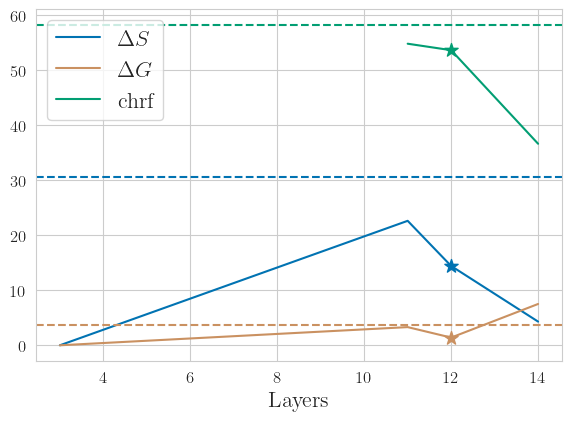

In [23]:
plot_line_plot(wmt_2tgt_res, mtg_res, lang='de', fact_thr=0.05, starred=12 , save_dir=OUTPUT_DIR, model_name=model_name)

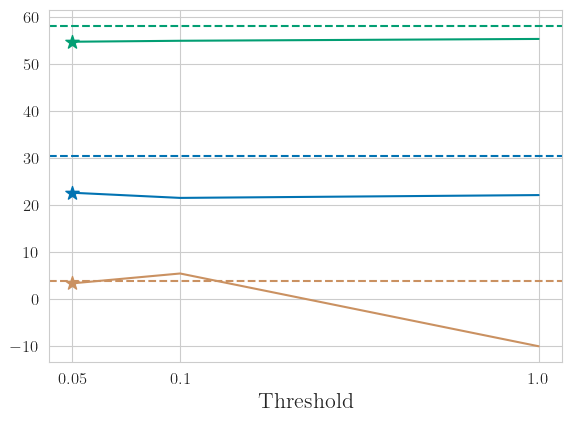

In [27]:
plot_line_plot(wmt_2tgt_res, mtg_res, lang='de', layers=11, starred=0.05, save_dir=OUTPUT_DIR, model_name=model_name)